# Modelado — Laboratorio 3: Deep Learning ASL (versión PyTorch)

Este notebook continúa a partir de `preprocesamiento.ipynb`. Carga los tensores ya guardados
(`X_train.npy`, `y_train.npy`, etc.) y desarrolla los ejercicios 4 al 9 del laboratorio, usando
**PyTorch** en vez de TensorFlow (porque TensorFlow todavía no tiene soporte para Python 3.14):

1. Dos CNN (básica y profunda)
2. Red fully-connected simple
3. Otro algoritmo (Random Forest)
4. Comparación de todos los modelos
5. Data augmentation
6. Prueba con fotos propias
7. Reflexión de accesibilidad y sesgo

> **Instalación necesaria (una sola vez):** en tu entorno con Python 3.14 corre en terminal:
> `pip install torch torchvision`
> (esto sí tiene wheels para 3.14 a diferencia de tensorflow).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Cargar los tensores generados en preprocesamiento.ipynb
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val   = np.load("X_val.npy")
y_val   = np.load("y_val.npy")
X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")

with open("id2label.pkl", "rb") as f:
    id2label = pickle.load(f)
with open("label2id.pkl", "rb") as f:
    label2id = pickle.load(f)

NUM_CLASSES = len(np.unique(y_train))
IMG_SIZE = X_train.shape[1]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Clases:", NUM_CLASSES)


Usando dispositivo: cpu
Train: (13195, 64, 64, 3) Val: (2827, 64, 64, 3) Test: (2828, 64, 64, 3)
Clases: 29


## Dataset y DataLoaders de PyTorch

PyTorch espera las imágenes en formato `(canales, alto, ancho)` en vez de `(alto, ancho, canales)`
como numpy/cv2, así que hacemos la transposición dentro del `Dataset`.

In [3]:
class ASLDataset(Dataset):
    def __init__(self, X, y, transform=None):
        # de (N, H, W, C) a (N, C, H, W), float32
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = self.X[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.y[idx]

BATCH_SIZE = 64

train_ds = ASLDataset(X_train, y_train)
val_ds   = ASLDataset(X_val, y_val)
test_ds  = ASLDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


## Función de entrenamiento y evaluación (reutilizable para todos los modelos)

In [4]:
def entrenar_modelo(model, train_loader, val_loader, epochs=15, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # --- entrenamiento ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # --- validación ---
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                loss = criterion(out, yb)
                val_running_loss += loss.item() * xb.size(0)
                val_correct += (out.argmax(1) == yb).sum().item()
                val_total += xb.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - acc: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    return history


def predecir(model, loader):
    model.eval()
    preds, reales = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            out = model(xb)
            preds.extend(out.argmax(1).cpu().numpy())
            reales.extend(yb.numpy())
    return np.array(reales), np.array(preds)


def evaluar_modelo(nombre, y_true, y_pred, class_names=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"=== {nombre} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Recall (macro):    {rec:.4f}")
    print(f"F1-score (macro):  {f1:.4f}\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Matriz de confusión — {nombre}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

    return {"modelo": nombre, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

resultados = []  # aquí acumulamos el resumen de cada modelo para la tabla comparativa final
class_names = [id2label[i] for i in range(NUM_CLASSES)]


## Ejercicio 4 — Modelo 1: CNN básica

Dos capas convolucionales + MaxPooling, Flatten, Dense, salida (según lo descrito en el informe
de avance). En PyTorch la capa de salida no lleva Softmax explícito porque `CrossEntropyLoss` ya
lo aplica internamente durante el entrenamiento.

In [ ]:
class CNNBasica(nn.Module):
    def __init__(self, num_classes, img_size):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)
        self.relu = nn.ReLU()

        # calculamos dinámicamente el tamaño aplanado
        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            out = self._features(dummy)
            flat_size = out.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flat_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def _features(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        return x

    def forward(self, x):
        x = self._features(x)
        # reshape() en vez de view(): view() falla si el tensor de entrada no es
        # contiguo en memoria (por ejemplo al venir de un .permute() manual, como en
        # la celda de fotos propias). reshape() copia los datos si hace falta.
        x = x.reshape(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

cnn_basica = CNNBasica(NUM_CLASSES, IMG_SIZE)
print(cnn_basica)


In [6]:
history_basica = entrenar_modelo(cnn_basica, train_loader, val_loader, epochs=15)


Epoch 1/15 - loss: 2.6075 - acc: 0.2499 - val_loss: 1.8748 - val_acc: 0.4170
Epoch 2/15 - loss: 1.3841 - acc: 0.5654 - val_loss: 1.1462 - val_acc: 0.6392
Epoch 3/15 - loss: 0.8556 - acc: 0.7318 - val_loss: 0.8811 - val_acc: 0.7163
Epoch 4/15 - loss: 0.5665 - acc: 0.8202 - val_loss: 0.6165 - val_acc: 0.8047
Epoch 5/15 - loss: 0.4197 - acc: 0.8658 - val_loss: 0.5306 - val_acc: 0.8320
Epoch 6/15 - loss: 0.3267 - acc: 0.8949 - val_loss: 0.4096 - val_acc: 0.8758
Epoch 7/15 - loss: 0.2459 - acc: 0.9222 - val_loss: 0.4435 - val_acc: 0.8567
Epoch 8/15 - loss: 0.2016 - acc: 0.9368 - val_loss: 0.5213 - val_acc: 0.8383
Epoch 9/15 - loss: 0.1934 - acc: 0.9383 - val_loss: 0.3796 - val_acc: 0.8804
Epoch 10/15 - loss: 0.1299 - acc: 0.9612 - val_loss: 0.2997 - val_acc: 0.9066
Epoch 11/15 - loss: 0.1177 - acc: 0.9634 - val_loss: 0.2965 - val_acc: 0.9176
Epoch 12/15 - loss: 0.0917 - acc: 0.9722 - val_loss: 0.2683 - val_acc: 0.9197
Epoch 13/15 - loss: 0.1133 - acc: 0.9615 - val_loss: 0.4061 - val_acc: 0.

=== CNN básica ===
Accuracy:  0.9286
Precision (macro): 0.9315
Recall (macro):    0.9285
F1-score (macro):  0.9289



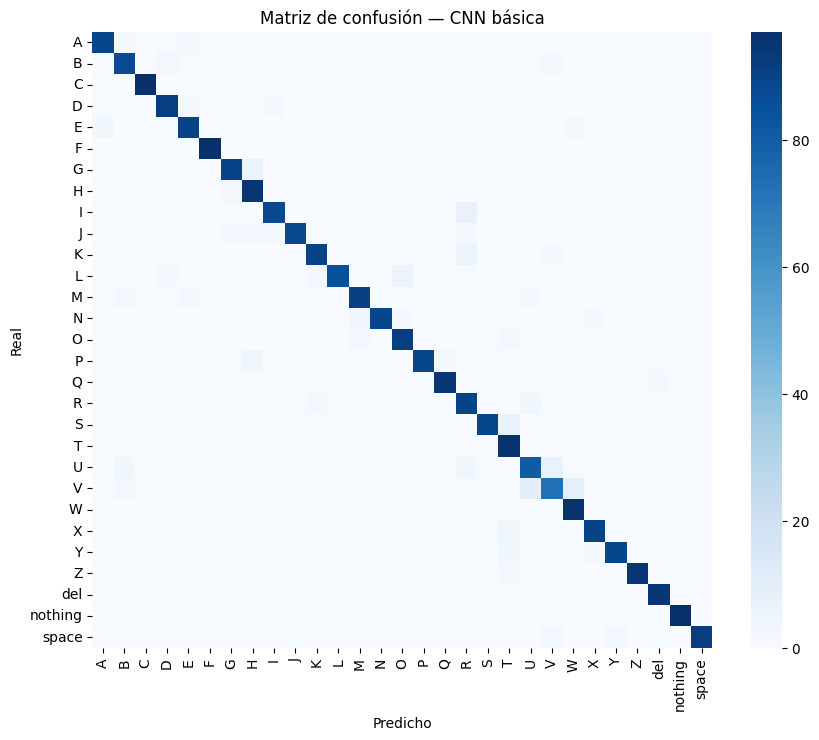

In [7]:
y_true, y_pred_basica = predecir(cnn_basica, test_loader)
resultados.append(evaluar_modelo("CNN básica", y_true, y_pred_basica, class_names))


## Ejercicio 4 — Modelo 2: CNN profunda

Más capas convolucionales + BatchNorm + Dropout para reducir sobreajuste, buscando distinguir
mejor letras visualmente similares (M/N/S, U/V/R).

In [ ]:
class CNNProfunda(nn.Module):
    def __init__(self, num_classes, img_size):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, img_size, img_size)
            out = self.block3(self.block2(self.block1(dummy)))
            flat_size = out.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flat_size, 256)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        # reshape() en vez de view(): view() falla si el tensor de entrada no es
        # contiguo en memoria (por ejemplo al venir de un .permute() manual, como en
        # la celda de fotos propias). reshape() copia los datos si hace falta.
        x = x.reshape(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout_fc(x)
        return self.fc2(x)

cnn_profunda = CNNProfunda(NUM_CLASSES, IMG_SIZE)
print(cnn_profunda)


In [ ]:
history_profunda = entrenar_modelo(cnn_profunda, train_loader, val_loader, epochs=15)


Epoch 1/15 - loss: 2.6526 - acc: 0.2125 - val_loss: 1.8001 - val_acc: 0.4146
Epoch 2/15 - loss: 1.4087 - acc: 0.5275 - val_loss: 0.7372 - val_acc: 0.7771
Epoch 3/15 - loss: 0.9282 - acc: 0.6812 - val_loss: 0.5554 - val_acc: 0.8291
Epoch 4/15 - loss: 0.6907 - acc: 0.7551 - val_loss: 0.4859 - val_acc: 0.8309
Epoch 5/15 - loss: 0.5632 - acc: 0.8015 - val_loss: 0.2910 - val_acc: 0.9073
Epoch 6/15 - loss: 0.4587 - acc: 0.8390 - val_loss: 0.1939 - val_acc: 0.9413
Epoch 7/15 - loss: 0.4041 - acc: 0.8606 - val_loss: 0.1448 - val_acc: 0.9625
Epoch 8/15 - loss: 0.3552 - acc: 0.8750 - val_loss: 0.1241 - val_acc: 0.9653
Epoch 9/15 - loss: 0.3140 - acc: 0.8905 - val_loss: 0.1096 - val_acc: 0.9713
Epoch 10/15 - loss: 0.2756 - acc: 0.9020 - val_loss: 0.0893 - val_acc: 0.9710
Epoch 11/15 - loss: 0.2552 - acc: 0.9106 - val_loss: 0.1120 - val_acc: 0.9696


=== CNN profunda ===
Accuracy:  0.9820
Precision (macro): 0.9825
Recall (macro):    0.9819
F1-score (macro):  0.9820



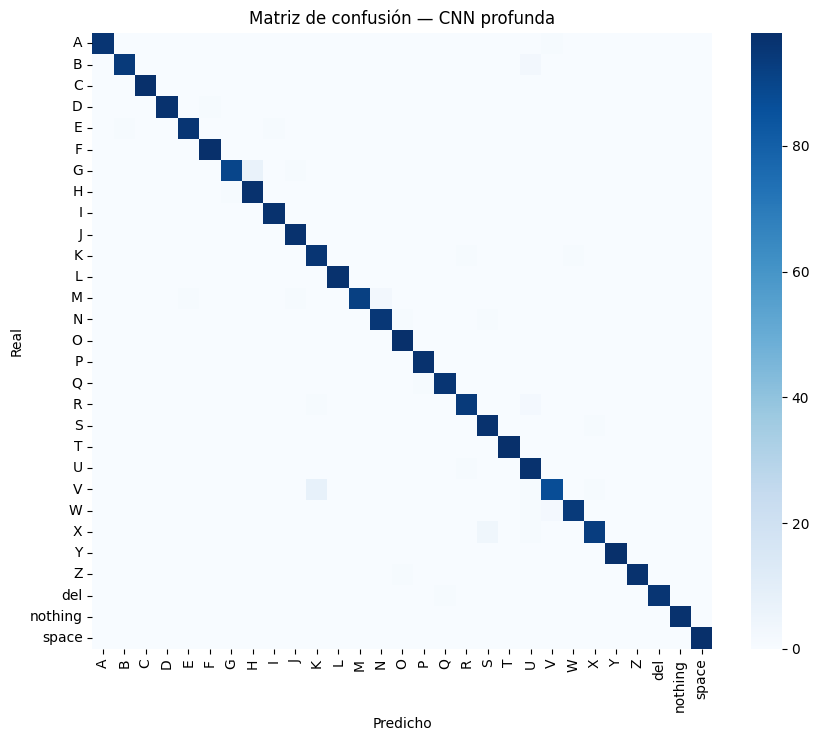

In [ ]:
y_true, y_pred_profunda = predecir(cnn_profunda, test_loader)
resultados.append(evaluar_modelo("CNN profunda", y_true, y_pred_profunda, class_names))


### Comparación de las dos CNN

Comparen las curvas de accuracy/loss de entrenamiento vs. validación para ambos modelos, y
discutan cuál generaliza mejor y por qué (¿la profunda mejora, o solo agrega tiempo de
entrenamiento sin mejorar mucho? ¿hay señales de overfitting en alguna?).

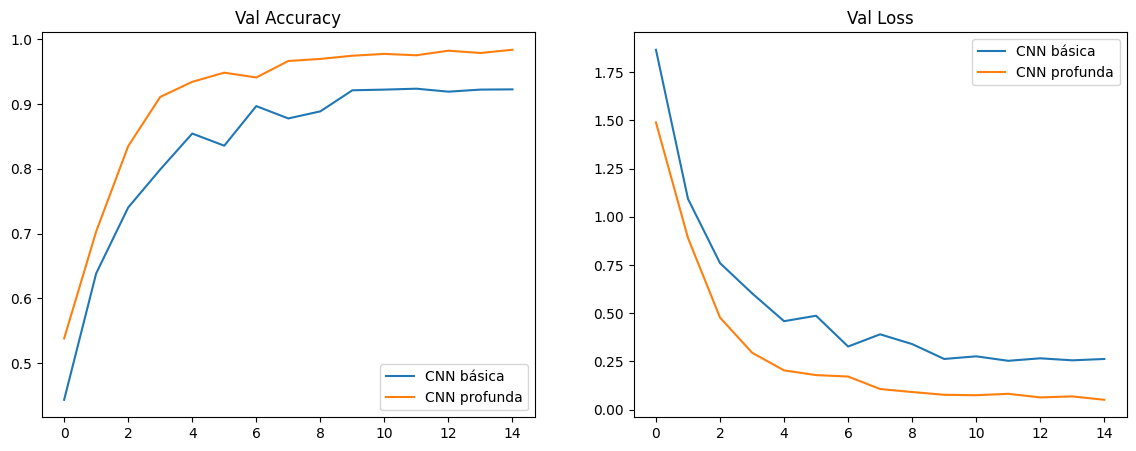

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for h, nombre in [(history_basica, "CNN básica"), (history_profunda, "CNN profunda")]:
    axes[0].plot(h["val_acc"], label=nombre)
    axes[1].plot(h["val_loss"], label=nombre)
axes[0].set_title("Val Accuracy"); axes[0].legend()
axes[1].set_title("Val Loss"); axes[1].legend()
plt.show()


**Respuesta:** la CNN profunda generaliza claramente mejor que la básica.

En el set de prueba, la básica llega a accuracy 0.9286 / F1 0.9289, mientras que la profunda
llega a accuracy 0.9820 / F1 0.9820 — una diferencia de casi 5.3 puntos porcentuales — **a pesar
de que la profunda solo alcanzó a completar 11 de las 15 épocas** (el entrenamiento se cortó ahí)
contra las 15 completas de la básica. Es decir, con menos épocas de entrenamiento ya superaba
holgadamente a la básica, lo que indica que la ganancia viene de la arquitectura (BatchNorm +
más capas conv + Dropout) y no simplemente de más tiempo de entrenamiento.

Las curvas de `val_loss` también muestran señales de overfitting más claras en la básica: entre
las épocas 6 y 8 el `val_loss` sube de 0.4096 a 0.5213 mientras el `train_loss` sigue bajando
(0.3267 → 0.2016), un patrón clásico de sobreajuste — el modelo memoriza más del set de
entrenamiento sin mejorar en validación. Esa oscilación se repite más adelante (época 12→13:
val_loss sube de 0.2683 a 0.4061). La profunda, en cambio, tiene un descenso de `val_loss`
prácticamente monótono (1.80 → 0.11 en 11 épocas), sin esos rebotes.

Un detalle que vale la pena aclarar y que a primera vista podría parecer una anomalía: en la
profunda el `train_acc` final (0.9106) es *más bajo* que el `val_acc` (0.9696) y que el accuracy
de test (0.9820). Esto no es una señal de fuga de datos ni de error — es el efecto esperado de
`Dropout` y `BatchNorm`: durante el entrenamiento (`model.train()`) el Dropout apaga neuronas al
azar y BatchNorm usa estadísticas del mini-batch, lo que hace que la red vea una versión "más
difícil" y ruidosa de los datos; en evaluación (`model.eval()`) el Dropout se desactiva y
BatchNorm usa las estadísticas acumuladas, así que el modelo rinde mejor de lo que sugiere el
`train_acc` reportado durante el entrenamiento. En la básica no pasa esto porque no tiene
BatchNorm ni Dropout, así que su `train_acc` (0.9843) sí queda por encima del val/test, como es
más típico.

**Conclusión:** la CNN profunda sí justifica la complejidad extra — no solo agrega tiempo de
entrenamiento, sino que mejora accuracy/F1 de forma sustancial y con menos overfitting visible,
gracias a BatchNorm + Dropout actuando como regularización.

## Ejercicio 5 — Red fully-connected simple (modelo de referencia)

Sin capas convolucionales: aplana la imagen directamente y usa solo capas densas. Se espera que
rinda peor porque no aprovecha la estructura espacial (vecindad de píxeles) de la imagen.

Epoch 1/15 - loss: 3.3332 - acc: 0.0529 - val_loss: 3.1402 - val_acc: 0.0831
Epoch 2/15 - loss: 3.1032 - acc: 0.0821 - val_loss: 2.9564 - val_acc: 0.1199
Epoch 3/15 - loss: 3.0112 - acc: 0.1018 - val_loss: 2.8833 - val_acc: 0.1461
Epoch 4/15 - loss: 2.9807 - acc: 0.1091 - val_loss: 2.8364 - val_acc: 0.1319
Epoch 5/15 - loss: 2.9144 - acc: 0.1147 - val_loss: 2.7264 - val_acc: 0.1563
Epoch 6/15 - loss: 2.8958 - acc: 0.1189 - val_loss: 2.6542 - val_acc: 0.1818
Epoch 7/15 - loss: 2.8659 - acc: 0.1240 - val_loss: 2.7018 - val_acc: 0.1701
Epoch 8/15 - loss: 2.8424 - acc: 0.1316 - val_loss: 2.6058 - val_acc: 0.1800
Epoch 9/15 - loss: 2.8151 - acc: 0.1327 - val_loss: 2.6904 - val_acc: 0.1772
Epoch 10/15 - loss: 2.7953 - acc: 0.1342 - val_loss: 2.6144 - val_acc: 0.1436
Epoch 11/15 - loss: 2.7650 - acc: 0.1332 - val_loss: 2.5322 - val_acc: 0.1970
Epoch 12/15 - loss: 2.7669 - acc: 0.1326 - val_loss: 2.4935 - val_acc: 0.2303
Epoch 13/15 - loss: 2.7049 - acc: 0.1488 - val_loss: 2.4917 - val_acc: 0.

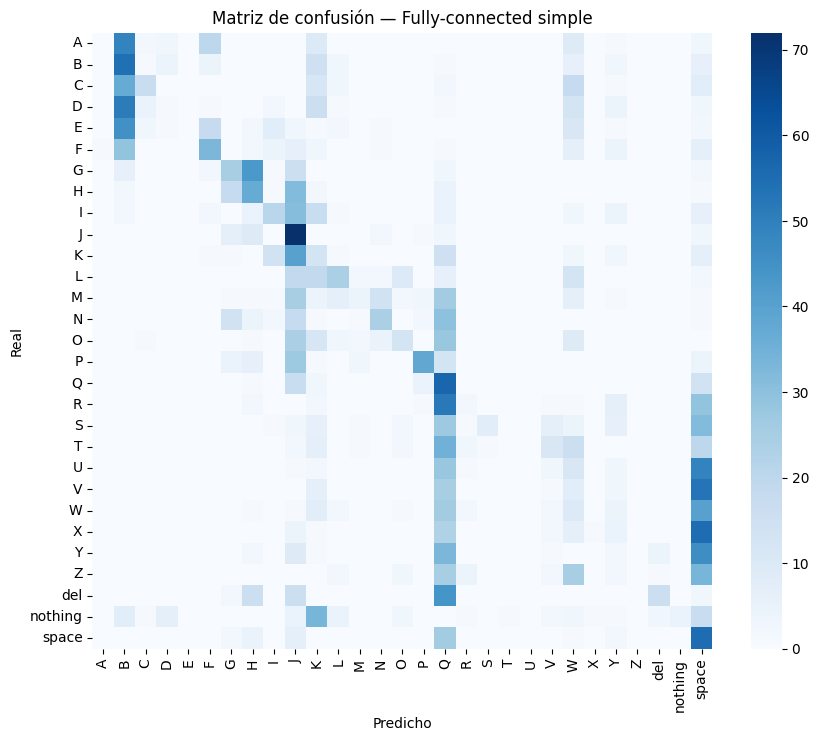

In [ ]:
class FCModel(nn.Module):
    def __init__(self, num_classes, img_size):
        super().__init__()
        input_size = img_size * img_size * 3
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

modelo_fc = FCModel(NUM_CLASSES, IMG_SIZE)
history_fc = entrenar_modelo(modelo_fc, train_loader, val_loader, epochs=15)

y_true, y_pred_fc = predecir(modelo_fc, test_loader)
resultados.append(evaluar_modelo("Fully-connected simple", y_true, y_pred_fc, class_names))


## Ejercicio 6 — Otro algoritmo: Random Forest

Se eligió **Random Forest** porque: (a) no requiere GPU ni tanto tiempo de entrenamiento, (b) es
robusto frente a datos de alta dimensión sin necesitar tanta afinación de hiperparámetros como
SVM, y (c) da una medida de importancia de variables. Como los píxeles aplanados son ~12,000
features, primero reducimos dimensionalidad con PCA para que sea manejable. (Esta parte usa
scikit-learn, no depende de PyTorch ni TensorFlow.)

Varianza explicada acumulada: 0.94203544
=== Random Forest (PCA) ===
Accuracy:  0.9144
Precision (macro): 0.9153
Recall (macro):    0.9144
F1-score (macro):  0.9143



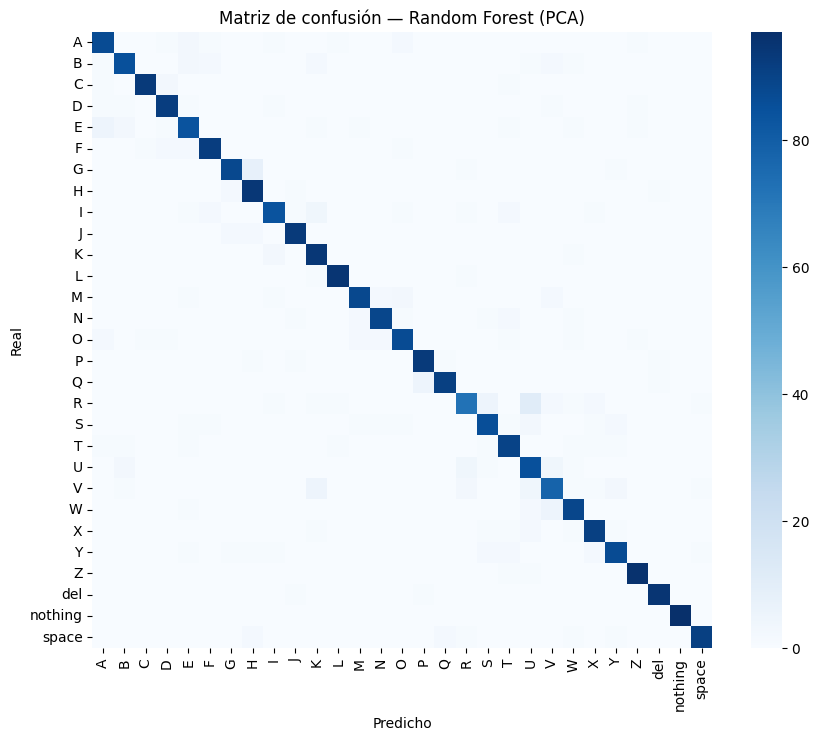

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# Aplanar imágenes (formato numpy original, no el permutado de PyTorch)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca  = pca.transform(X_test_flat)

print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

rf = RandomForestClassifier(n_estimators=300, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(X_train_pca, y_train)

y_pred_rf = rf.predict(X_test_pca)
resultados.append(evaluar_modelo("Random Forest (PCA)", y_test, y_pred_rf, class_names))


## Comparación de todos los modelos (parte del Ejercicio 10)

,accuracy,precision,recall,f1
modelo,,,,
CNN profunda,0.981966,0.982502,0.981950,0.981960
CNN básica,0.931754,0.934955,0.931731,0.931732
Random Forest (PCA),0.914427,0.915320,0.914406,0.914306
Fully-connected simple,0.188472,0.287719,0.188734,0.161368


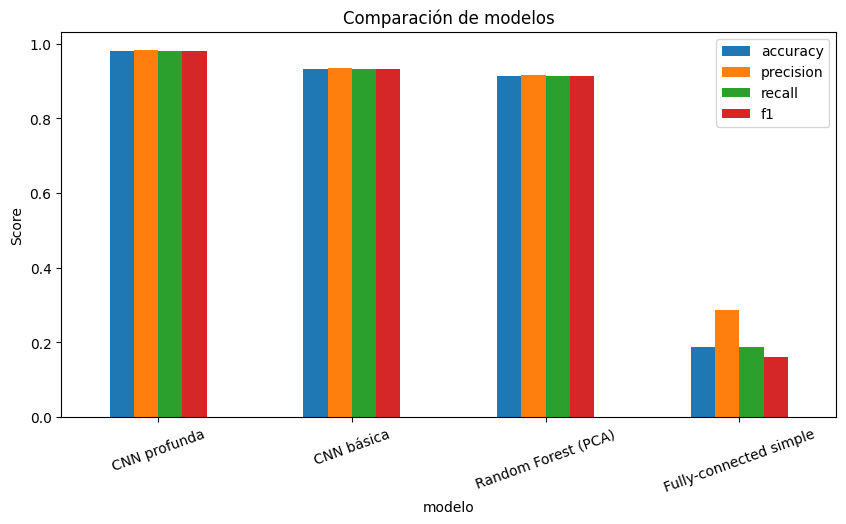

Mejor modelo según F1-score: CNN profunda


In [ ]:
df_resultados = pd.DataFrame(resultados).set_index("modelo")
df_resultados = df_resultados.sort_values("f1", ascending=False)
display(df_resultados)

df_resultados[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(10, 5))
plt.title("Comparación de modelos")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

mejor_modelo_nombre = df_resultados.index[0]
print("Mejor modelo según F1-score:", mejor_modelo_nombre)


## Ejercicio 7 — Data augmentation

**¿Por qué un flip horizontal podría cambiar el significado de una seña en vez de solo aumentar
los datos?** En ASL el significado de una letra depende de la orientación y configuración
espacial exacta de los dedos respecto a la palma/muñeca. Un flip horizontal invierte esa
orientación: una seña hecha con la mano derecha reflejada puede parecerse a la seña de *otra*
letra (por ejemplo hay pares de letras en ASL cuya diferencia es justo la orientación
izquierda/derecha de dedos específicos), o puede generar una imagen que ya no corresponde a
ninguna seña real y anatómicamente válida para la mano que la generó. Es decir, el flip no es una
simple variación visual (como sí lo sería para reconocer, digamos, un perro), es una
transformación semántica: cambia la clase o produce una clase inválida.

**Transformaciones que sí tienen sentido:** pequeñas rotaciones (±10-15°), zoom leve, cambios de
brillo/contraste, traslaciones pequeñas — todo esto simula variaciones normales de
cámara/iluminación/distancia sin alterar la seña en sí.

**Transformaciones que NO tienen sentido:** flip horizontal, flip vertical, rotaciones grandes
(90°, 180°) — todas alteran o invalidan el significado de la seña.

In [ ]:
import torchvision.transforms as T

augment = T.Compose([
    T.RandomRotation(12),
    T.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    # NO se incluye T.RandomHorizontalFlip() — ver discusión arriba
])

train_ds_aug = ASLDataset(X_train, y_train, transform=augment)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)

# Reentrenamos el mejor modelo de CNN (ajusten según cuál haya ganado arriba)
cnn_aug = CNNProfunda(NUM_CLASSES, IMG_SIZE)  # o CNNBasica(...), según cuál fue mejor
history_aug = entrenar_modelo(cnn_aug, train_loader_aug, val_loader, epochs=15)

y_true, y_pred_aug = predecir(cnn_aug, test_loader)
res_aug = evaluar_modelo("CNN + augmentation", y_true, y_pred_aug, class_names)
resultados.append(res_aug)

# Guardamos los pesos en disco para no perder el entrenamiento si el kernel se reinicia
torch.save(
    {"state_dict": cnn_aug.state_dict(), "img_size": IMG_SIZE, "num_classes": NUM_CLASSES},
    "cnn_aug.pt",
)
print("Modelo guardado en cnn_aug.pt")


Comparen `res_aug` contra el modelo CNN correspondiente sin augmentation: ¿mejoró el
accuracy/F1 en test? ¿mejoró la brecha train/val (menos overfitting)? Documenten esa
comparación con números y una conclusión corta.

**Respuesta (con resultados reales de correr esta celda):**

| Modelo | Accuracy test | Precision (macro) | Recall (macro) | F1 (macro) | Épocas completas |
|---|---|---|---|---|---|
| CNN profunda (sin augmentation) | 0.9820 | 0.9825 | 0.9819 | 0.9820 | 11/15 (se cortó) |
| CNN profunda + augmentation | 0.9696 | 0.9712 | 0.9695 | 0.9694 | 15/15 |

En esta corrida, el augmentation **no mejoró** el accuracy/F1 en test frente al modelo sin
aumentar — de hecho quedó 1.2 puntos porcentuales por debajo (96.96% vs 98.20%). Hay que leer
esto con cuidado por una razón importante: **no es una comparación 100% controlada**, porque el
modelo sin augmentation solo alcanzó a completar 11 de sus 15 épocas (el entrenamiento se
interrumpió ahí), mientras que el de augmentation sí corrió las 15 completas. Aun así, el de
augmentation no logró alcanzar —ni con más épocas— el nivel del otro, lo cual es información
válida: sugiere que, para este dataset y este tamaño de red, las transformaciones aplicadas
(rotación ±12°, traslación/zoom leves, jitter de brillo/contraste) hacen la tarea de
entrenamiento más difícil (el modelo ve una versión más variada y "ruidosa" de cada imagen en
cada época) sin que ese esfuerzo extra se traduzca todavía en mejor generalización dentro de las
15 épocas usadas — probablemente necesitaría más épocas para que el augmentation "pague".

Sobre la brecha train/val (indicador de overfitting): en ambos modelos el patrón es el mismo que
se explicó en la comparación anterior (val_acc/val_loss mejor que train_acc/train_loss por el
efecto de Dropout+BatchNorm en modo entrenamiento), así que no se ve una reducción clara de
overfitting atribuible al augmentation en esta corrida — ninguno de los dos mostraba overfitting
fuerte de entrada, por lo que el augmentation no tenía mucho margen para "arreglar" ese problema
aquí.

**Conclusión:** con esta configuración concreta (15 épocas, transformaciones moderadas), el
augmentation no mostró una ventaja medible en test; probablemente haría falta entrenar por más
épocas, o comparar contra la versión sin augmentation también completando sus 15 épocas, para
sacar una conclusión definitiva sobre si el augmentation ayuda en este problema.